# Install Libraries

In [ ]:
!pip install transformers datasets evaluate seqeval accelerate -q

# Import Libraries

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import evaluate

import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

warnings.filterwarnings("ignore")

# Loading Dataset

In [ ]:
df = pd.read_csv("/content/sample_data/BoroPOStag.csv")

print(df.shape)

df.head()

(6000, 159)


,ID\tValue,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 149,Unnamed: 150,Unnamed: 151,Unnamed: 152,Unnamed: 153,Unnamed: 154,Unnamed: 155,Unnamed: 156,Unnamed: 157,Unnamed: 158
0,BDHED1\tदेहास्रि\N_NN,होननानै\V_VM,बुंब्ला\V_VM,गोरों\N_NN,गोराफोरा\N_NN,गुबुन\JJ,गुबुन\JJ,आयदायाव\N_NN,साननोगोनां\V_VM,जायो\V_VM,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BDHED10\tहोमब्लासो\CC_CCS,जों\PR_PRP,माहारि\N_NN,हान्जा\N_NN,फारसेबो\N_NST,देहास्रि\N_NN,गोगो\JJ,होनजागोन\V_VM,।\RD_PUNC,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BDHED100\tखिनानै\V_VM,फैब्ला\V_VM,आखायखौ\N_NN,साबोनजों\N_NN,सुनांगौ\V_VM,।\RD_PUNC,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BDHED1000\tगान्दुनि\N_NN,जिआ\N_NN,साफा\JJ,जानाया\V_VM,मोजां\JJ,।\RD_PUNC,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BDHED101\tमैला-मैलि\N_NN,गैयै\RB,जानांगौ\V_VM,।\RD_PUNC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Dataset Cleaning

In [ ]:
import pandas as pd

# Helper function to split 'word\TAG' string
def split_word_tag(text):
    if pd.isna(text) or not isinstance(text, str):
        return None, None
    # Split by the last backslash to separate word and tag
    parts = text.rsplit('\\', 1)
    if len(parts) == 2:
        word = parts[0]
        tag = parts[1]
        # Check if the tag part is not empty
        if tag and tag.strip() != '':
            return word.strip(), tag.strip()
    # If no backslash, or tag part is empty, assume the whole text is a word
    # and assign a default 'O' tag.
    return text.strip(), 'O'

# Initialize lists to store processed data
sentences_data = []
tags_data = []

# Iterate over each row of the DataFrame to construct 'Sentence' and 'Tags'
for idx, row in df.iterrows():
    current_sentence_words = []
    current_tags = []

    # Process the 'ID\tValue' column first
    first_col_content = row['ID\tValue']
    if pd.notna(first_col_content) and isinstance(first_col_content, str):
        # First, split by '\t' to separate the ID from the word\tag part
        id_parts = first_col_content.split('\t', 1)
        if len(id_parts) == 2:
            word_tag_part = id_parts[1]
            word, tag = split_word_tag(word_tag_part)
            if word and word.strip():
                current_sentence_words.append(word)
                current_tags.append(tag)
        else: # Case where 'ID\tValue' might only contain 'word\tag' or just 'word' without ID
            word, tag = split_word_tag(first_col_content)
            if word and word.strip():
                current_sentence_words.append(word)
                current_tags.append(tag)

    # Process all 'Unnamed: X' columns
    for col in df.columns:
        if col.startswith('Unnamed:') and pd.notna(row[col]):
            cell_content = row[col]
            word, tag = split_word_tag(cell_content)
            if word and word.strip():
                current_sentence_words.append(word)
                current_tags.append(tag)

    sentences_data.append(" ".join(current_sentence_words))
    tags_data.append(" ".join(current_tags))

# Add the new 'Sentence' and 'Tags' columns to the DataFrame
df['Sentence'] = sentences_data
df['Tags'] = tags_data

# Now apply the original cleaning steps

# Remove empty rows based on 'Sentence' column
df = df[df['Sentence'].str.strip() != '']
df = df[df['Tags'].str.strip() != '']

# Remove duplicate sentences
df = df.drop_duplicates(subset=["Sentence"])

# Strip whitespace
df["Sentence"] = df["Sentence"].str.strip()
df["Tags"] = df["Tags"].str.strip()

# Reset index
df = df.reset_index(drop=True)

print(df.shape)

(5988, 161)


# Remove Sentence-Tag Mismatch

In [ ]:
valid_rows = []

for _, row in df.iterrows():

    words = row["Sentence"].split()

    tags = row["Tags"].split()

    if len(words) == len(tags):
        valid_rows.append(row)

df = pd.DataFrame(valid_rows)

df = df.reset_index(drop=True)

print(df.shape)

(5988, 161)


Corpus Statistics

In [ ]:
sentences = df["Sentence"].tolist()

total_sentences = len(sentences)

total_words = sum(len(s.split()) for s in sentences)

vocab = set()

sentence_lengths = []

for s in sentences:

    words = s.split()

    sentence_lengths.append(len(words))

    vocab.update(words)

print("Sentences :", total_sentences)

print("Words :", total_words)

print("Vocabulary :", len(vocab))

print("Average Sentence Length :", np.mean(sentence_lengths))

print("Maximum Length :", np.max(sentence_lengths))

print("Minimum Length :", np.min(sentence_lengths))

Sentences : 5988
Words : 90488
Vocabulary : 21229
Average Sentence Length : 15.111556446225785
Maximum Length : 159
Minimum Length : 1


In [ ]:
# Extract all POS tags from the dataset
all_tags = []

for tags_str in df["Tags"]:
    all_tags.extend(tags_str.split())   # Split tag sequence into individual tags

# Get unique POS tags
unique_tags = sorted(set(all_tags))

print("Total POS Tags:", len(unique_tags))
print(unique_tags)

Total POS Tags: 35
['CC_CCD', 'CC_CCS', 'DM_DMD', 'DM_DMI', 'DM_DMQ', 'DM_DMR', 'JJ', 'N_NN', 'N_NNP', 'N_NST', 'PR_PRC', 'PR_PRF', 'PR_PRI', 'PR_PRL', 'PR_PRP', 'PR_PRQ', 'PSP', 'QT_QTC', 'QT_QTF', 'QT_QTO', 'RB', 'RD_ECH', 'RD_PUNC', 'RD_RDF', 'RD_SYM', 'RD_UNK', 'RP_INJ', 'RP_INTF', 'RP_NEG', 'RP_RPD', 'V_VAUX', 'V_VAUX_VF', 'V_VM', 'V_VM_VF', 'V_VM_VNF']


In [ ]:
from collections import Counter

tag_freq = Counter(all_tags)

tag_df = (
    pd.DataFrame(tag_freq.items(), columns=["POS Tag", "Count"])
      .sort_values(by="Count", ascending=False)
      .reset_index(drop=True)
)

tag_df

,POS Tag,Count
0,N_NN,23238
1,V_VM,17319
2,RD_PUNC,13268
3,N_NNP,9797
4,JJ,5344
5,N_NST,3366
6,QT_QTC,2498
7,CC_CCD,2456
8,DM_DMD,2302
9,PSP,1943


In [ ]:
label2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2label = {idx: tag for tag, idx in label2id.items()}

print(label2id)

{'CC_CCD': 0, 'CC_CCS': 1, 'DM_DMD': 2, 'DM_DMI': 3, 'DM_DMQ': 4, 'DM_DMR': 5, 'JJ': 6, 'N_NN': 7, 'N_NNP': 8, 'N_NST': 9, 'PR_PRC': 10, 'PR_PRF': 11, 'PR_PRI': 12, 'PR_PRL': 13, 'PR_PRP': 14, 'PR_PRQ': 15, 'PSP': 16, 'QT_QTC': 17, 'QT_QTF': 18, 'QT_QTO': 19, 'RB': 20, 'RD_ECH': 21, 'RD_PUNC': 22, 'RD_RDF': 23, 'RD_SYM': 24, 'RD_UNK': 25, 'RP_INJ': 26, 'RP_INTF': 27, 'RP_NEG': 28, 'RP_RPD': 29, 'V_VAUX': 30, 'V_VAUX_VF': 31, 'V_VM': 32, 'V_VM_VF': 33, 'V_VM_VNF': 34}


# Word Frequecy

In [ ]:
all_words = []

for sentence in sentences:
    all_words.extend(sentence.split())

word_freq = Counter(all_words)

freq_df = pd.DataFrame(
    word_freq.items(),
    columns=["Word","Frequency"]
).sort_values(
    by="Frequency",
    ascending=False
)

freq_df.head(20)

,Word,Frequency
9,।,5841
96,",",3209
79,आरो,1569
197,),1215
194,(,1202
256,बे,1155
355,-,742
8,जायो,477
58,एबा,430
566,मोनसे,420


# POS Tag Distribution

In [ ]:
all_tags = []

for tags in df["Tags"]:
    all_tags.extend(tags.split())

tag_freq = Counter(all_tags)

tag_df = pd.DataFrame(
    tag_freq.items(),
    columns=["POS","Count"]
).sort_values(
    by="Count",
    ascending=False
)

tag_df

,POS,Count
0,N_NN,23238
1,V_VM,17319
3,RD_PUNC,13268
9,N_NNP,9797
2,JJ,5344
6,N_NST,3366
13,QT_QTC,2498
10,CC_CCD,2456
12,DM_DMD,2302
8,PSP,1943


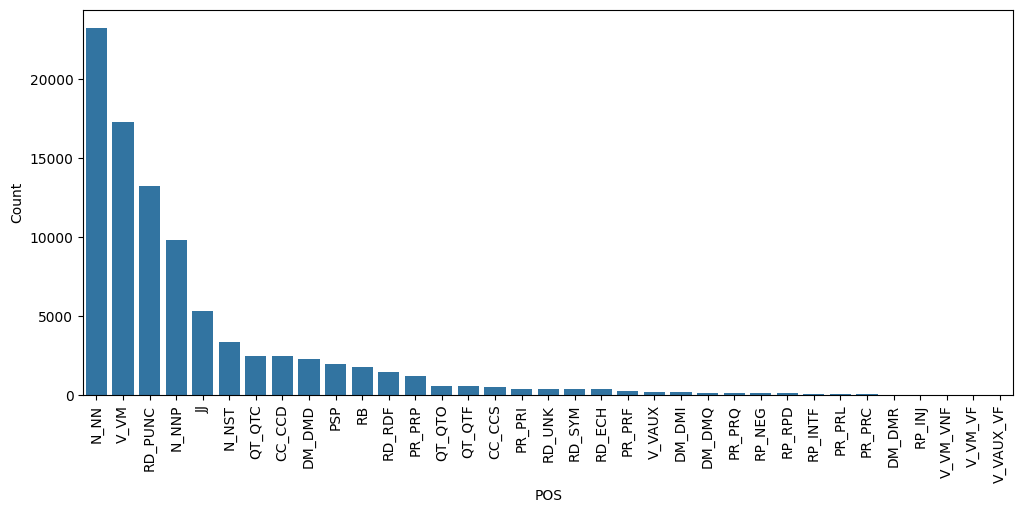

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(data=tag_df,
            x="POS",
            y="Count")

plt.xticks(rotation=90)

plt.show()

# Label Mapping

In [ ]:
labels = sorted(tag_freq.keys())

label2id = {
    label:i
    for i,label in enumerate(labels)
}

id2label = {
    i:label
    for label,i in label2id.items()
}

print(label2id)

{'CC_CCD': 0, 'CC_CCS': 1, 'DM_DMD': 2, 'DM_DMI': 3, 'DM_DMQ': 4, 'DM_DMR': 5, 'JJ': 6, 'N_NN': 7, 'N_NNP': 8, 'N_NST': 9, 'PR_PRC': 10, 'PR_PRF': 11, 'PR_PRI': 12, 'PR_PRL': 13, 'PR_PRP': 14, 'PR_PRQ': 15, 'PSP': 16, 'QT_QTC': 17, 'QT_QTF': 18, 'QT_QTO': 19, 'RB': 20, 'RD_ECH': 21, 'RD_PUNC': 22, 'RD_RDF': 23, 'RD_SYM': 24, 'RD_UNK': 25, 'RP_INJ': 26, 'RP_INTF': 27, 'RP_NEG': 28, 'RP_RPD': 29, 'V_VAUX': 30, 'V_VAUX_VF': 31, 'V_VM': 32, 'V_VM_VF': 33, 'V_VM_VNF': 34}


# Train Validation Test Split

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

4790
599
599


# Load IndicBERT v2 Tokenizer

In [ ]:
MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenization + Label Alignment

In [ ]:
def tokenize_and_align_labels(examples):
    # Split sentences into words as required by is_split_into_words=True
    words_batch = [sentence.split() for sentence in examples["Sentence"]]

    tokenized_inputs = tokenizer(
        words_batch, # Pass the list of lists of words
        truncation=True,
        padding="max_length",
        max_length=128,
        is_split_into_words=True
    )

    labels = []

    for i, tags_str in enumerate(examples["Tags"]):
        tags = tags_str.split() # Split the string of tags into a list

        word_ids = tokenized_inputs.word_ids(batch_index=i)

        previous_word_idx = None

        label_ids = []

        for word_idx in word_ids:

            # Special tokens
            if word_idx is None:
                label_ids.append(-100)

            # First token of a word
            elif word_idx != previous_word_idx:
                # Ensure word_idx is within the bounds of the 'tags' list
                if word_idx is not None and word_idx < len(tags):
                    label_ids.append(label2id[tags[word_idx]])
                else:
                    label_ids.append(-100) # Assign -100 for out-of-bound tags or None word_idx
            # Remaining subword pieces
            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

# Convert to HuggingFace Dataset

In [ ]:
train_dataset = Dataset.from_pandas(train_df).map(tokenize_and_align_labels, batched=True)
val_dataset = Dataset.from_pandas(val_df).map(tokenize_and_align_labels, batched=True)
test_dataset = Dataset.from_pandas(test_df).map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/4790 [00:00<?, ? examples/s]

Map:   0%|          | 0/599 [00:00<?, ? examples/s]

Map:   0%|          | 0/599 [00:00<?, ? examples/s]

# Data Collator

In [ ]:
collator = DataCollatorForTokenClassification(tokenizer)

# Load Model

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	ca

# Metric

In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        for p, l in zip(pred, lab):
            if l != -100:
                true_predictions.append(id2label[p])
                true_labels.append(id2label[l])

    accuracy = accuracy_score(true_labels, true_predictions)

    # Standard (Weighted)
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        true_predictions,
        average="weighted",
        zero_division=0
    )

    _, _, macro_f1, _ = precision_recall_fscore_support(
        true_labels,
        true_predictions,
        average="macro",
        zero_division=0
    )

    _, _, micro_f1, _ = precision_recall_fscore_support(
        true_labels,
        true_predictions,
        average="micro",
        zero_division=0
    )

    _, _, weighted_f1, _ = precision_recall_fscore_support(
        true_labels,
        true_predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,                    # Standard F1 (Weighted)
        "macro_f1": macro_f1,
        "micro_f1": micro_f1,
        "weighted_f1": weighted_f1
    }

# Training Arguments

In [ ]:
training_args = TrainingArguments(

    output_dir="outputs",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=12,

    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="eval_macro_f1",

    logging_steps=100,

    report_to="none"
)

# Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Micro F1,Weighted F1
1,0.793220,0.707889,0.801998,0.782515,0.801998,0.784611,0.347023,0.801998,0.784611
2,0.603669,0.584125,0.831758,0.813574,0.831758,0.820737,0.441094,0.831758,0.820737
3,0.522791,0.543716,0.838818,0.829190,0.838818,0.830718,0.500066,0.838818,0.830718
4,0.454788,0.524225,0.845878,0.842425,0.845878,0.840440,0.554098,0.845878,0.840440
5,0.404049,0.506121,0.854024,0.851130,0.854024,0.850871,0.587602,0.854024,0.850871


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2700, training_loss=0.517367017534044, metrics={'train_runtime': 1739.8411, 'train_samples_per_second': 33.037, 'train_steps_per_second': 2.069, 'total_flos': 2816965989619200.0, 'train_loss': 0.517367017534044, 'epoch': 9.0})

# Evaluation on test set

In [ ]:
trainer.evaluate(test_dataset)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Macro F1,Micro F1,Weighted F1
0.287504,0.514362,9,0.855063,0.853634,0.855063,0.853139,0.627589,0.855063,0.853139


{'eval_loss': 0.5143620371818542,
 'eval_accuracy': 0.8550626481544192,
 'eval_precision': 0.8536344996592313,
 'eval_recall': 0.8550626481544192,
 'eval_f1': 0.8531393029815028,
 'eval_macro_f1': 0.6275888314784,
 'eval_micro_f1': 0.8550626481544192,
 'eval_weighted_f1': 0.8531393029815028}

# Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get predictions
predictions, labels, _ = trainer.predict(test_dataset)

predictions = np.argmax(predictions, axis=2)

true_predictions = []
true_labels = []

for prediction, label in zip(predictions, labels):
    pred_tags = []
    true_tags = []

    for p, l in zip(prediction, label):
        if l != -100:
            pred_tags.append(id2label[p])
            true_tags.append(id2label[l])

    true_predictions.extend(pred_tags)
    true_labels.extend(true_tags)

print(classification_report(
    true_labels,
    true_predictions,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      CC_CCD     0.8478    0.9249    0.8847       253
      CC_CCS     0.6111    0.4889    0.5432        45
      DM_DMD     0.9456    0.9658    0.9556       234
      DM_DMI     0.5333    0.3636    0.4324        22
      DM_DMQ     0.5833    0.7778    0.6667         9
      DM_DMR     0.0000    0.0000    0.0000         2
          JJ     0.7006    0.6966    0.6986       524
        N_NN     0.8632    0.8298    0.8462      2244
       N_NNP     0.8508    0.8412    0.8460       976
       N_NST     0.6803    0.6596    0.6698       329
      PR_PRC     1.0000    0.2222    0.3636         9
      PR_PRF     0.6154    0.8000    0.6957        30
      PR_PRI     0.5625    0.7297    0.6353        37
      PR_PRL     0.4545    1.0000    0.6250         5
      PR_PRP     0.8621    0.8475    0.8547       118
      PR_PRQ     0.0000    0.0000    0.0000         4
         PSP     0.7892    0.7487    0.7684       195
      QT_QTC     0.7654    

# Confusion Matrix

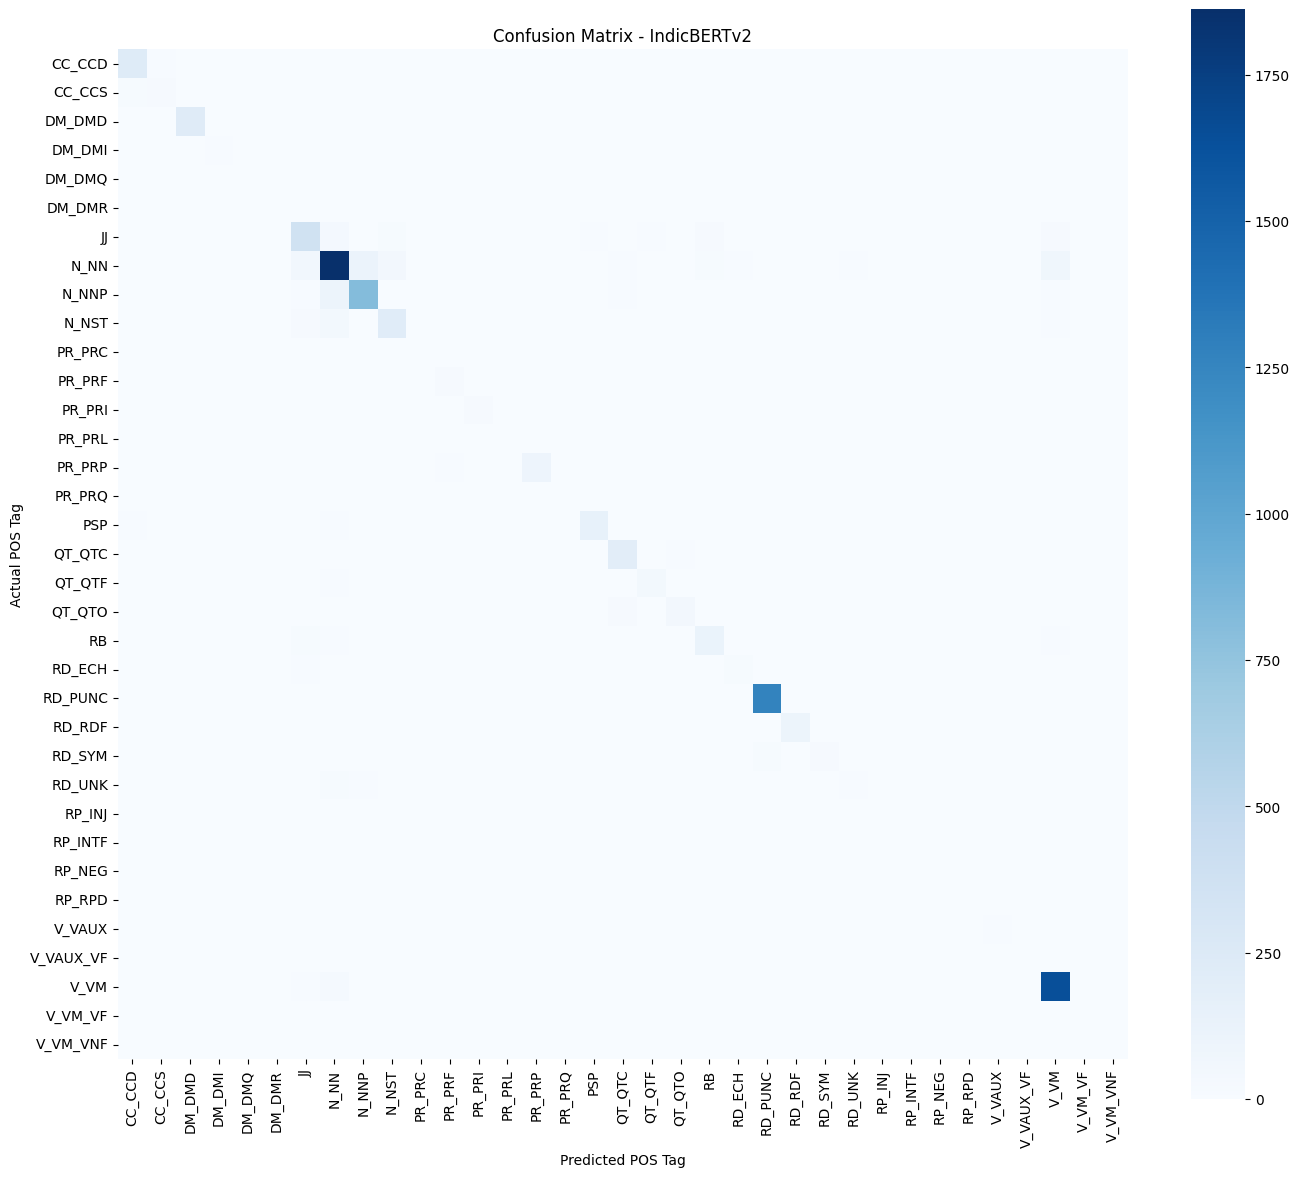

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels_list = sorted(label2id.keys())

cm = confusion_matrix(
    true_labels,
    true_predictions,
    labels=labels_list
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels_list,
    yticklabels=labels_list,
    square=True
)

plt.xlabel("Predicted POS Tag")
plt.ylabel("Actual POS Tag")
plt.title("Confusion Matrix - IndicBERTv2")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Error Analysis.
This prints the first 20 wrongly predicted sentences.

In [ ]:
wrong = 0

print("="*100)

for i in range(len(test_dataset)):

    prediction = predictions[i]
    label = labels[i]

    pred_tags = []
    true_tags = []

    for p, l in zip(prediction, label):
        if l != -100:
            pred_tags.append(id2label[p])
            true_tags.append(id2label[l])

    if pred_tags != true_tags:

        print(f"\nSentence {i+1}")

        print("Words :")
        print(test_df.iloc[i]["Sentence"])

        print("\nTrue Tags :")
        print(" ".join(true_tags))

        print("\nPredicted Tags :")
        print(" ".join(pred_tags))

        print("-"*100)

        wrong += 1

    if wrong == 20:
        break


Sentence 1
Words :
खाया नांनाय खुदियानि लैखोन - खाया नांजानाय खुदियाफोरा सरासनस्रायै जोबोर खां - खां जायो ।

True Tags :
JJ N_NN N_NN JJ RD_PUNC JJ V_VM N_NN RB RP_INTF JJ RD_PUNC RD_ECH V_VM RD_PUNC

Predicted Tags :
V_VM V_VM N_NN JJ RD_PUNC RD_ECH V_VM N_NN RB RP_INTF JJ RD_PUNC JJ V_VM RD_PUNC
----------------------------------------------------------------------------------------------------

Sentence 2
Words :
भारतारि हाइनारि हाथरखि छानिया मिर्जाया पेसिफिक लाइफ अ’पेनाव गाज्रि रोखोमै फाइनेलनि सिगाङाव थाद’नोगोनां जाहैबाय ।

True Tags :
N_NNP JJ N_NN N_NNP N_NNP N_NNP N_NNP N_NNP JJ RB N_NN N_NST V_VM V_VM RD_PUNC

Predicted Tags :
JJ N_NN N_NN N_NNP N_NNP N_NN N_NN N_NN RB RB N_NN N_NST V_VM V_VM RD_PUNC
----------------------------------------------------------------------------------------------------

Sentence 3
Words :
नाथाय जोंनायनि दोहौ गोलाउआ ( wavelength ) से मिटारनि ब्रै कौटि बाहागोनिफ्राय दाइन कौटि बाहागोनि बाहागोसेनि मादाव थायो ।

True Tags :
CC_CCD V_VM N_NN JJ RD_PUNC

# Saving the Best Model

In [ ]:
SAVE_PATH = "IndicBERTv2_Bodo_POS"

trainer.save_model(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print(f"Model saved successfully to '{SAVE_PATH}'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully to 'IndicBERTv2_Bodo_POS'


# Loss Curves

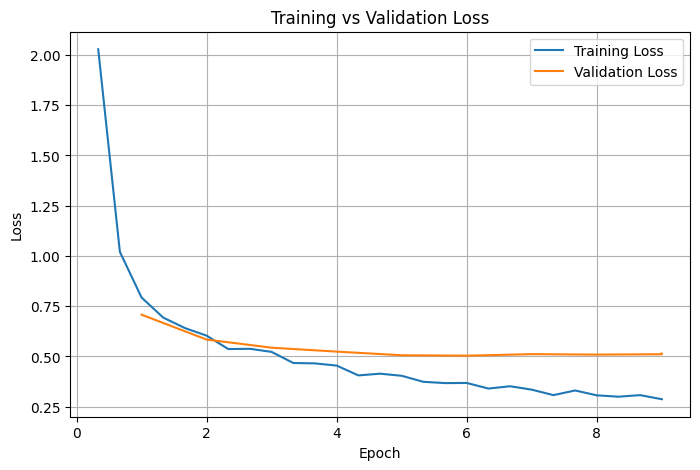

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

train_loss = history[history["loss"].notna()]
eval_loss = history[history["eval_loss"].notna()]

plt.figure(figsize=(8,5))

plt.plot(train_loss["epoch"], train_loss["loss"], label="Training Loss")
plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

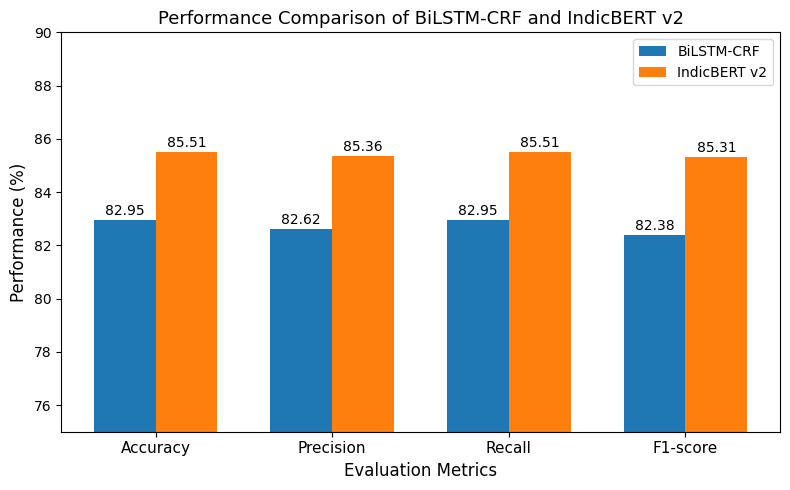

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# BiLSTM-CRF results
bilstm = [82.95, 82.62, 82.95, 82.38]

# IndicBERT v2 results
indicbert = [85.51, 85.36, 85.51, 85.31]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, bilstm, width, label='BiLSTM-CRF')
plt.bar(x + width/2, indicbert, width, label='IndicBERT v2')

plt.xticks(x, metrics, fontsize=11)
plt.ylabel('Performance (%)', fontsize=12)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.title('Performance Comparison of BiLSTM-CRF and IndicBERT v2', fontsize=13)

plt.ylim(75, 90)
plt.legend()

# Display values on bars
for i, v in enumerate(bilstm):
    plt.text(i - width/2, v + 0.2, f'{v:.2f}', ha='center', fontsize=10)

for i, v in enumerate(indicbert):
    plt.text(i + width/2, v + 0.2, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()